In [2]:
# Libraries
import os
import numpy as np
import cv2
from PIL import Image
import shutil
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"
classes = ['open_eyes', 'closed_eyes']

print("Libraries imported!")

Libraries imported!


In [3]:
# Resize all images to 64x64 and greyscale
resized = 0

for class_name in classes:
    class_path = os.path.join(processed_path, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((64, 64), Image.LANCZOS)
            img.save(img_path)
            resized += 1
        except Exception as e:
            print(f"Error: {img_path} - {e}")

print(f"Resized {resized} images to 64x64 L")

Resized 9464 images to 64x64 L


In [4]:
# Augmentation - balance open_eyes to match closed_eyes count
augment_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

open_eyes_path = os.path.join(processed_path, 'open_eyes')
open_images    = os.listdir(open_eyes_path)
current_count  = len(open_images)
target_count   = len(os.listdir(os.path.join(processed_path, 'closed_eyes')))
needed         = target_count - current_count

print(f"open_eyes current : {current_count}")
print(f"closed_eyes count : {target_count}")
print(f"Images needed     : {needed}")

aug_count = 0

# Generate augmented images until open_eyes matches closed_eyes
for img_name in random.choices(open_images, k=needed):
    img_path  = os.path.join(open_eyes_path, img_name)
    img       = load_img(img_path, color_mode='grayscale')
    img_array = img_to_array(img).reshape(1, 64, 64, 1)

    for batch in augment_datagen.flow(img_array, batch_size=1):
        aug_img  = array_to_img(batch[0])
        save_name = f"aug_{aug_count}.jpg"
        aug_img.save(os.path.join(open_eyes_path, save_name))
        aug_count += 1
        break

print(f"\nAugmented {aug_count} images added to open_eyes")
print(f"open_eyes new count: {len(os.listdir(open_eyes_path))}")

open_eyes current : 4399
closed_eyes count : 5065
Images needed     : 666

Augmented 666 images added to open_eyes
open_eyes new count: 5065


open_eyes: 5065 images
closed_eyes: 5065 images

Sizes : {(64, 64)}
Modes : {'L'}


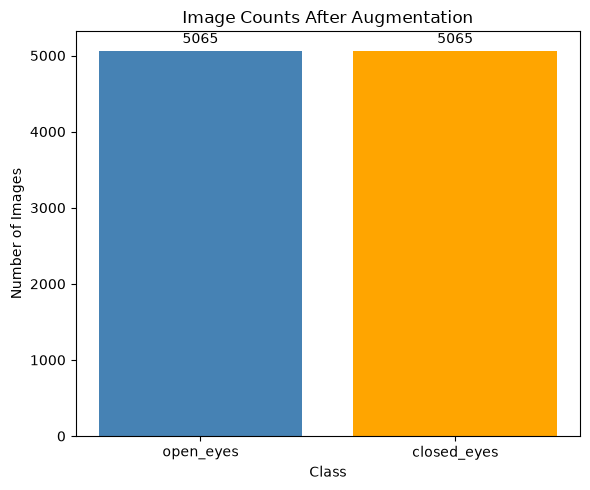

In [6]:
import matplotlib.pyplot as plt

# Verify images after augmentation
sizes = set()
modes = set()

for class_name in classes:
    class_path = os.path.join(processed_path, class_name)
    count = len(os.listdir(class_path))
    
    # Check sizes and modes
    for img_name in os.listdir(class_path):
        img = Image.open(os.path.join(class_path, img_name))
        sizes.add(img.size)
        modes.add(img.mode)
    
    print(f"{class_name}: {count} images")

print(f"\nSizes : {sizes}")
print(f"Modes : {modes}")

# Bar chart
counts = [len(os.listdir(os.path.join(processed_path, c))) for c in classes]
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, counts, color=['steelblue', 'orange'])
ax.set_title('Image Counts After Augmentation')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

In [7]:
# Train/Test Split (80/20)
random.seed(42)

for class_name in classes:
    class_path = os.path.join(processed_path, class_name)

    # Create train and test folders
    train_folder = os.path.join(processed_path, 'train', class_name)
    test_folder  = os.path.join(processed_path, 'test', class_name)
    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)

    # Get all images
    all_images = os.listdir(class_path)
    random.shuffle(all_images)

    # Split 80/20
    split_idx  = int(0.8 * len(all_images))
    train_imgs = all_images[:split_idx]
    test_imgs  = all_images[split_idx:]

    # Copy to train folder
    for img_name in train_imgs:
        shutil.copy(os.path.join(class_path, img_name),
                    os.path.join(train_folder, img_name))

    # Copy to test folder
    for img_name in test_imgs:
        shutil.copy(os.path.join(class_path, img_name),
                    os.path.join(test_folder, img_name))

    print(f"{class_name}: {len(train_imgs)} train | {len(test_imgs)} test")

open_eyes: 4052 train | 1013 test
closed_eyes: 4052 train | 1013 test


In [8]:
# Verify normalization on sample image
import numpy as np
from PIL import Image

sample_path = os.path.join(processed_path, 'train', 'open_eyes')
img_name = os.listdir(sample_path)[0]
img = Image.open(os.path.join(sample_path, img_name))
img_array = np.array(img)

print(f"Before normalization:")
print(f"  Min : {img_array.min()}")
print(f"  Max : {img_array.max()}")
print(f"  Mean: {img_array.mean():.2f}")

# Normalize to 0-1
img_normalized = img_array / 255.0

print(f"\nAfter normalization:")
print(f"  Min : {img_normalized.min()}")
print(f"  Max : {img_normalized.max():.4f}")
print(f"  Mean: {img_normalized.mean():.4f}")

print("\nNormalization check done!")

Before normalization:
  Min : 0
  Max : 255
  Mean: 121.08

After normalization:
  Min : 0.0
  Max : 1.0000
  Mean: 0.4748

Normalization check done!
